## 1. Problema

## 2. Dataset

In [48]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [49]:
df = pd.read_csv('dataset_banco_clean.csv')

In [50]:
print(df.shape)
df.head()

(45189, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


## 3. Analisis exploratorio de datos
    - 1. Analisis de cada variable individual
    - 2. Analisis univariado: relacion entre variable predictora con variable a predecir
    - 3. Analisis bivariado: relacion de pares de variables predictoras con la variable a predecir

### 3.1 Analisis de cada variable individual

In [51]:
df.info()# Revisar variables categoricas 

<class 'pandas.DataFrame'>
RangeIndex: 45189 entries, 0 to 45188
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45189 non-null  int64  
 1   job        45189 non-null  str    
 2   marital    45189 non-null  str    
 3   education  45189 non-null  str    
 4   default    45189 non-null  str    
 5   balance    45189 non-null  float64
 6   housing    45189 non-null  str    
 7   loan       45189 non-null  str    
 8   contact    45189 non-null  str    
 9   day        45189 non-null  int64  
 10  month      45189 non-null  str    
 11  duration   45189 non-null  float64
 12  campaign   45189 non-null  int64  
 13  pdays      45189 non-null  float64
 14  previous   45189 non-null  int64  
 15  poutcome   45189 non-null  str    
 16  y          45189 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 5.9 MB


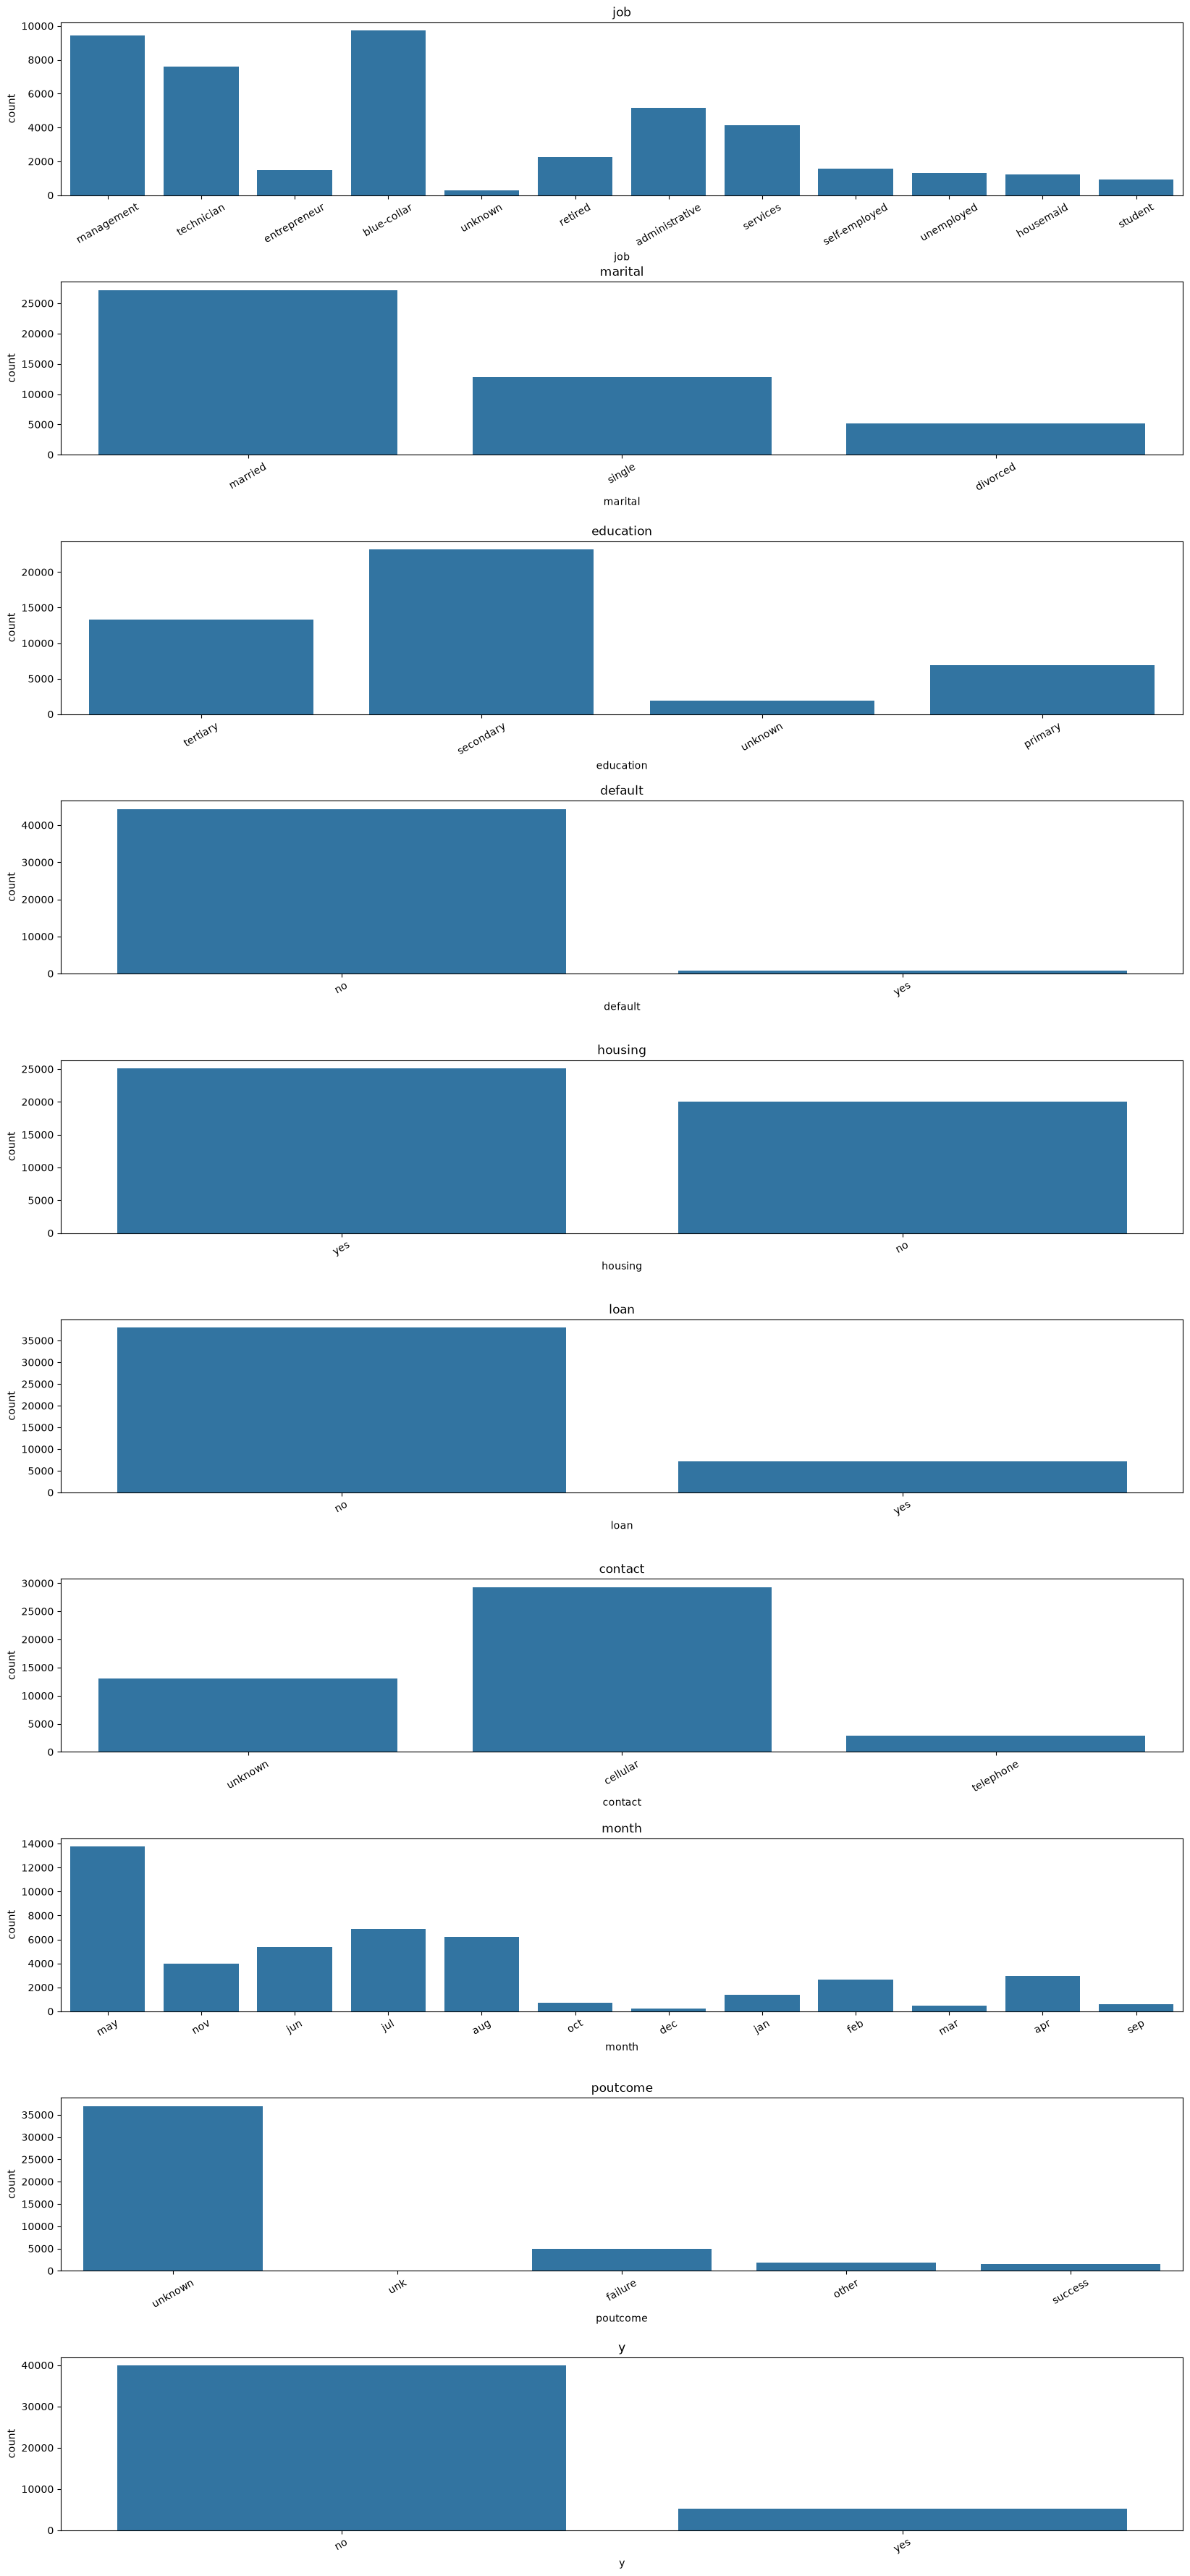

In [52]:
col_cat = ['job', 'marital','education', 'default', 'housing', 'loan', 'contact', 'month','poutcome','y']
fig, ax = plt.subplots(nrows = len(col_cat), ncols =1, figsize =(20,45))
fig.subplots_adjust(hspace=0.5)
for i,col in enumerate(col_cat):
    sns.countplot(x=col, data=df, ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis='x', labelrotation=30)

In [53]:
# Eliminamos columnas que no aportan info relevante sobre el cliente 
df.drop(columns=['contact','month','day','duration','campaign','pdays', 'previous'], inplace=True, errors='ignore')

In [54]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'poutcome', 'y'],
      dtype='str')

In [56]:
# Variables numerica EDAD y Saldo, estadisticas descriptivas basicas
df.describe()

,age,balance
count,45189.000000,45189.000000
mean,40.936445,1374.012149
std,10.618502,3924.370039
min,18.000000,-8019.000000
25%,33.000000,72.000000
50%,39.000000,448.000000
75%,48.000000,1428.000000
max,95.000000,527532.000000


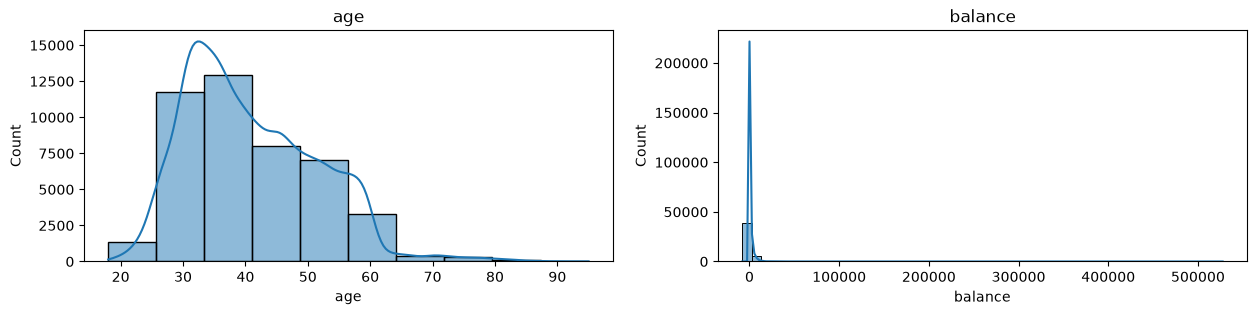

In [65]:
col_num =['age','balance']

fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(15,3))
fig.subplots_adjust(hspace=0.5) 

for i,col in enumerate(col_num):
    if col == 'age':
        nbins = 10
    elif col == 'balance':
        nbins = 50
    sns.histplot(x=col, data=df, ax=ax[i], bins=nbins, kde=True)
    ax[i].set_title(col)
 

**Observaciones**
- *La mayor parte del grupo tiene entre 30 y 50 años, con un sesgo hacia los 30-40 años*
- *El 75% tiene saldo negativo o que no supera los 1500 euros*

In [68]:
df['balance'].describe()

count     45189.000000
mean       1374.012149
std        3924.370039
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      527532.000000
Name: balance, dtype: float64